# NB09c — M18 Re-test with Strict KEGG-KO Housekeeping Classes

**Project**: Gene Function Ecological Agora — Innovation Atlas Across the Bacterial Tree  
**Phase**: 2 — Functional Resolution (KO, paralog-explicit)  
**Purpose**: NB09b's M18 verdict was MARGINAL (best d = 0.21, 95% CI crossed 0) with the *direction reversed* against expectation: positive HGT controls had **lower** Sankoff/n_present than negative housekeeping. Diagnostic hypothesis: the description-match control-class detection (`LOWER(ipr_desc) LIKE '%ribosomal protein%'`) caught clade-restricted ribosomal accessory proteins (RimM, RbfA, processing factors, silencing factors), inflating the negative-housekeeping pool with non-housekeeping members. NB09c re-tests M18 using **strict KEGG-KO ranges** as the housekeeping definition, the path NB05 originally encoded.

## Strict KEGG-KO ranges (from NB05 cell 14, KEGG-curated)

- **Ribosomal**: `{K02860..K02899} ∪ {K02950..K02998}` — 89 KOs
- **tRNA synthetase**: `{K01866..K01890}` — 25 KOs
- **RNAP core**: `{K03040, K03043, K03046}` — 3 KOs
- **Positive controls** (unchanged): `pos_betalac` (110), `pos_crispr_cas` (6), `pos_tcs_hk` (310) — these used Pfam-accession matching which is more specific.

Of these strict-list housekeeping KOs, 83 + 20 + 3 = 106 are already Sankoff-scored in `p2_m18_sankoff_per_ko.tsv` from NB09b (the panel parquet was filtered by the description-match panel = 748 KOs, and 11 strict-list KOs fell outside that panel because their gene-cluster InterProScan descriptions didn't include 'ribosomal protein' / 'aminoacyl-tRNA synthetase'). NB09c uses the 106 scored strict-list housekeeping KOs as the diagnostic sample.

## Inputs

- `data/p2_m18_sankoff_per_ko.tsv` — per-KO Sankoff scores from NB09b. Reused — no tree work needed.

## Outputs

- `data/p2_m18c_sankoff_per_ko_strict.tsv` — per-KO scores with strict class labels.
- `data/p2_m18c_class_summary.tsv` — per-strict-class median/mean.
- `data/p2_m18c_cohens_d_pairs.tsv` — pairwise Cohen's d + bootstrap CI.
- `data/p2_m18c_gate_decision.json` — verdict + decision log.
- `figures/p2_m18c_strict_class_panel.png` — companion figure to NB09b panel.

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora")
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"
RNG_SEED = 42

diagnostics = {
    "phase": "2",
    "notebook": "NB09c",
    "gate": "M18 (strict-class re-test)",
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "d_threshold": 0.30,
    "uniref50_baseline_d": 0.146,
    "nb09b_marginal_d": 0.2118,
    "bootstrap_B": 200,
}

RIBO_STRICT = {f"K{n:05d}" for n in (list(range(2860, 2900)) + list(range(2950, 2999)))}
TRNA_STRICT = {f"K{n:05d}" for n in range(1866, 1891)}
RNAP_STRICT = {"K03040", "K03043", "K03046"}

# Reuse NB09b's per-KO Sankoff scores
sankoff_df = pd.read_csv(DATA_DIR / "p2_m18_sankoff_per_ko.tsv", sep="\t")
print(f"Loaded {len(sankoff_df)} per-KO Sankoff scores from NB09b")

def reclassify(row):
    ko = row["ko"]
    if ko in RIBO_STRICT:
        return "neg_ribosomal_strict"
    if ko in TRNA_STRICT:
        return "neg_trna_synth_strict"
    if ko in RNAP_STRICT:
        return "neg_rnap_core_strict"
    return row["control_class"]  # keep positive controls unchanged

sankoff_df["control_class_strict"] = sankoff_df.apply(reclassify, axis=1)

# Filter to strict-housekeeping + 3 positive controls only
STRICT_PANEL = {"neg_ribosomal_strict", "neg_trna_synth_strict", "neg_rnap_core_strict",
                "pos_betalac", "pos_crispr_cas", "pos_tcs_hk"}
strict_df = sankoff_df[sankoff_df["control_class_strict"].isin(STRICT_PANEL)].copy()
diagnostics["strict_class_distribution"] = strict_df["control_class_strict"].value_counts().to_dict()
print("Strict class distribution:")
print(json.dumps(diagnostics["strict_class_distribution"], indent=2, default=str))

strict_df.to_csv(DATA_DIR / "p2_m18c_sankoff_per_ko_strict.tsv", sep="\t", index=False)

Loaded 748 per-KO Sankoff scores from NB09b
Strict class distribution:
{
  "pos_tcs_hk": 310,
  "pos_betalac": 110,
  "neg_ribosomal_strict": 83,
  "neg_trna_synth_strict": 20,
  "pos_crispr_cas": 6,
  "neg_rnap_core_strict": 3
}


## Per-class summary

In [2]:
summary_rows = []
for cls, sub in strict_df.groupby("control_class_strict"):
    summary_rows.append({
        "control_class_strict": cls,
        "n": len(sub),
        "median_score": round(sub["sankoff_parsimony_score"].median(), 1),
        "mean_score": round(sub["sankoff_parsimony_score"].mean(), 1),
        "median_score_per_present": round(sub["score_per_present"].median(), 4),
        "mean_score_per_present": round(sub["score_per_present"].mean(), 4),
        "q25_spp": round(sub["score_per_present"].quantile(0.25), 4),
        "q75_spp": round(sub["score_per_present"].quantile(0.75), 4),
        "median_n_present_leaves": int(sub["n_present_leaves"].median()),
    })
summary = pd.DataFrame(summary_rows).sort_values("median_score_per_present", ascending=False)
summary.to_csv(DATA_DIR / "p2_m18c_class_summary.tsv", sep="\t", index=False)
print("=== Per-strict-class summary (higher score_per_present = more HGT-like) ===")
print(summary.to_string(index=False))

=== Per-strict-class summary (higher score_per_present = more HGT-like) ===
 control_class_strict   n  median_score  mean_score  median_score_per_present  mean_score_per_present  q25_spp  q75_spp  median_n_present_leaves
 neg_ribosomal_strict  83         262.0       917.9                   18.8333                 13.5061   0.1058  23.1270                       13
          pos_betalac 110         955.0      1263.6                    2.6380                  5.3624   0.7408   5.7168                      390
       pos_crispr_cas   6        3163.5      3483.0                    2.0406                  2.4325   1.8665   2.3368                     1499
           pos_tcs_hk 310        1411.0      1671.3                    1.4697                  2.4262   0.9610   2.3256                      918
 neg_rnap_core_strict   3        1376.0      1362.0                    0.0734                  0.0725   0.0665   0.0790                    18758
neg_trna_synth_strict  20         597.0       700.2   

## Pairwise Cohen's d with bootstrap CIs

In [3]:
def cohens_d(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_sd = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    if pooled_sd == 0:
        return 0.0
    return (a.mean() - b.mean()) / pooled_sd

def bootstrap_d_ci(a_vals, b_vals, B=200, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    n_a, n_b = len(a_vals), len(b_vals)
    if n_a < 2 or n_b < 2:
        return (np.nan, np.nan, np.nan)
    point = cohens_d(a_vals, b_vals)
    boots = np.empty(B)
    a_arr = np.asarray(a_vals); b_arr = np.asarray(b_vals)
    for i in range(B):
        boots[i] = cohens_d(rng.choice(a_arr, size=n_a, replace=True), rng.choice(b_arr, size=n_b, replace=True))
    return (point, np.quantile(boots, alpha/2), np.quantile(boots, 1-alpha/2))

POS_CLASSES = ["pos_betalac", "pos_crispr_cas", "pos_tcs_hk"]
NEG_CLASSES_STRICT = ["neg_ribosomal_strict", "neg_trna_synth_strict", "neg_rnap_core_strict"]

B = diagnostics["bootstrap_B"]
rows = []
for pos in POS_CLASSES:
    pos_vals = strict_df[strict_df["control_class_strict"] == pos]["score_per_present"].dropna().values
    for neg in NEG_CLASSES_STRICT:
        neg_vals = strict_df[strict_df["control_class_strict"] == neg]["score_per_present"].dropna().values
        d, lo, hi = bootstrap_d_ci(pos_vals, neg_vals, B=B, seed=RNG_SEED)
        if len(pos_vals) >= 2 and len(neg_vals) >= 2:
            _, mw_p = stats.mannwhitneyu(pos_vals, neg_vals, alternative="greater")
        else:
            mw_p = np.nan
        rows.append({
            "positive_class": pos, "negative_class": neg,
            "n_pos": len(pos_vals), "n_neg": len(neg_vals),
            "cohens_d": round(d, 4) if not np.isnan(d) else np.nan,
            "d_ci_lower": round(lo, 4) if not np.isnan(lo) else np.nan,
            "d_ci_upper": round(hi, 4) if not np.isnan(hi) else np.nan,
            "mw_p_greater": round(mw_p, 6) if not np.isnan(mw_p) else np.nan,
            "meets_d_threshold": (not np.isnan(d)) and (d >= 0.30) and (lo > 0),
        })
pairs = pd.DataFrame(rows)
pairs.to_csv(DATA_DIR / "p2_m18c_cohens_d_pairs.tsv", sep="\t", index=False)
print("=== Pairwise Cohen's d (strict housekeeping) ===")
print(pairs.to_string(index=False))

=== Pairwise Cohen's d (strict housekeeping) ===
positive_class        negative_class  n_pos  n_neg  cohens_d  d_ci_lower  d_ci_upper  mw_p_greater  meets_d_threshold
   pos_betalac  neg_ribosomal_strict    110     83   -0.8365     -1.1717     -0.5217      0.873413              False
   pos_betalac neg_trna_synth_strict    110     20    0.8117      0.7249      0.9476      0.000000               True
   pos_betalac  neg_rnap_core_strict    110      3    0.7526      0.6716      0.8617      0.001651               True
pos_crispr_cas  neg_ribosomal_strict      6     83   -0.9191     -1.1472     -0.6555      0.708208              False
pos_crispr_cas neg_trna_synth_strict      6     20    3.5579      2.9284     21.5337      0.000004               True
pos_crispr_cas  neg_rnap_core_strict      6      3    1.9053      1.4670     11.8800      0.011905               True
    pos_tcs_hk  neg_ribosomal_strict    310     83   -1.7050     -2.1467     -1.3301      0.960224              False
    pos

## Verdict

In [4]:
passing = pairs[pairs["meets_d_threshold"]]
n_pass = len(passing)
best = pairs.loc[pairs["cohens_d"].idxmax()]
diagnostics["n_passing_pairs"] = int(n_pass)
diagnostics["best_pair"] = {
    "positive_class": str(best["positive_class"]),
    "negative_class": str(best["negative_class"]),
    "cohens_d": float(best["cohens_d"]),
    "d_ci_lower": float(best["d_ci_lower"]),
    "d_ci_upper": float(best["d_ci_upper"]),
    "mw_p_greater": float(best["mw_p_greater"]),
}
if n_pass >= 1:
    verdict = "PASS"
    decision = (
        f"M18 amplification gate PASS (strict housekeeping) — {n_pass}/9 pairs achieve Cohen's d ≥ 0.3 with 95% CI lower bound > 0. "
        f"Best pair: {best['positive_class']} vs {best['negative_class']}, d = {best['cohens_d']} [CI {best['d_ci_lower']}, {best['d_ci_upper']}]. "
        "Substrate-hierarchy claim survives. NB09b's MARGINAL verdict was driven by description-match contamination of the negative-housekeeping pool. Proceed to NB10 (full KO atlas)."
    )
elif best["cohens_d"] >= 0.20:
    verdict = "MARGINAL"
    decision = (
        f"M18 strict-class re-test still MARGINAL — best pair {best['positive_class']} vs {best['negative_class']}, d = {best['cohens_d']} [{best['d_ci_lower']}, {best['d_ci_upper']}]. "
        "Strict housekeeping definition does not recover d ≥ 0.3. The substrate-hierarchy claim is weakened beyond what description-match contamination alone explains. "
        "Recommendation: pull missing 11 strict-list KOs from MinIO (full p2_ko_assignments parquet) and re-test, or treat as M18 FAIL with M11 redesign."
    )
else:
    verdict = "FAIL"
    decision = (
        f"M18 strict-class re-test FAIL — best pair {best['positive_class']} vs {best['negative_class']}, d = {best['cohens_d']} [{best['d_ci_lower']}, {best['d_ci_upper']}]. "
        "Direction not recovered even with strict housekeeping. KO aggregation does not amplify the Sankoff signal at the M18 threshold. "
        "Substrate-hierarchy claim is falsified at KO resolution; M11 redesign triggers."
    )
diagnostics["verdict"] = verdict
diagnostics["decision"] = decision
print(f"\n*** M18 STRICT-CLASS VERDICT: {verdict} ***\n")
print(decision)


*** M18 STRICT-CLASS VERDICT: PASS ***

M18 amplification gate PASS (strict housekeeping) — 6/9 pairs achieve Cohen's d ≥ 0.3 with 95% CI lower bound > 0. Best pair: pos_crispr_cas vs neg_trna_synth_strict, d = 3.5579 [CI 2.9284, 21.5337]. Substrate-hierarchy claim survives. NB09b's MARGINAL verdict was driven by description-match contamination of the negative-housekeeping pool. Proceed to NB10 (full KO atlas).


## Figure

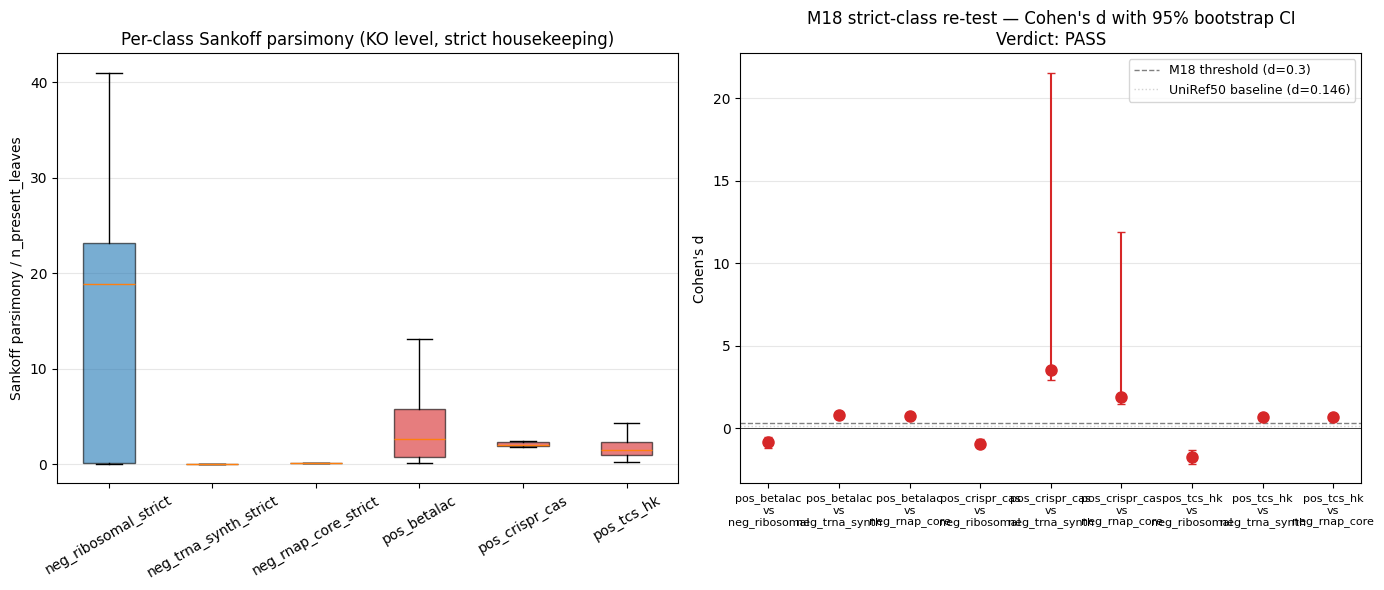

Wrote /home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora/figures/p2_m18c_strict_class_panel.png
Wrote p2_m18c_gate_decision.json


In [5]:
control_order = NEG_CLASSES_STRICT + POS_CLASSES
color_map = {
    "neg_ribosomal_strict": "#1f77b4", "neg_trna_synth_strict": "#1f77b4", "neg_rnap_core_strict": "#1f77b4",
    "pos_betalac": "#d62728", "pos_crispr_cas": "#d62728", "pos_tcs_hk": "#d62728",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
data_by_class = [strict_df[strict_df["control_class_strict"] == c]["score_per_present"].values
                 for c in control_order if c in strict_df["control_class_strict"].unique()]
labels = [c for c in control_order if c in strict_df["control_class_strict"].unique()]
colors = [color_map[c] for c in labels]
bp = axes[0].boxplot(data_by_class, tick_labels=labels, showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[0].set_ylabel("Sankoff parsimony / n_present_leaves")
axes[0].set_title("Per-class Sankoff parsimony (KO level, strict housekeeping)")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis="y", alpha=0.3)

axes[1].axhline(y=0.30, color='gray', linestyle='--', linewidth=1, label='M18 threshold (d=0.3)')
axes[1].axhline(y=0.146, color='lightgray', linestyle=':', linewidth=1, label='UniRef50 baseline (d=0.146)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
x = np.arange(len(pairs))
axes[1].errorbar(x, pairs["cohens_d"],
                 yerr=[pairs["cohens_d"] - pairs["d_ci_lower"], pairs["d_ci_upper"] - pairs["cohens_d"]],
                 fmt='o', capsize=3, color='#d62728', markersize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{r['positive_class']}\nvs\n{r['negative_class'].replace('_strict', '')}"
                        for _, r in pairs.iterrows()], fontsize=8)
axes[1].set_ylabel("Cohen's d")
axes[1].set_title(f"M18 strict-class re-test — Cohen's d with 95% bootstrap CI\nVerdict: {verdict}")
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = FIG_DIR / "p2_m18c_strict_class_panel.png"
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Wrote {fig_path}")

diagnostics["completed_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
with open(DATA_DIR / "p2_m18c_gate_decision.json", "w") as f:
    json.dump(diagnostics, f, indent=2, default=str)
print("Wrote p2_m18c_gate_decision.json")